# Day 10 - Explore and Visualize

## Topic
Explore and visualize

## Summary
- Discover and visualize data
- Geographical plots
- Feature distributions
- Early pattern discovery

## Practice
- Create at least two plots
- Write one insight from each plot

## 1. Load example data

We use the California Housing dataset for exploration and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_style('whitegrid')
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Basic dataset overview

Check the main columns and summary statistics.

In [2]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 3. Plot 1: Median income distribution

This histogram shows how the median income values are distributed in the dataset.

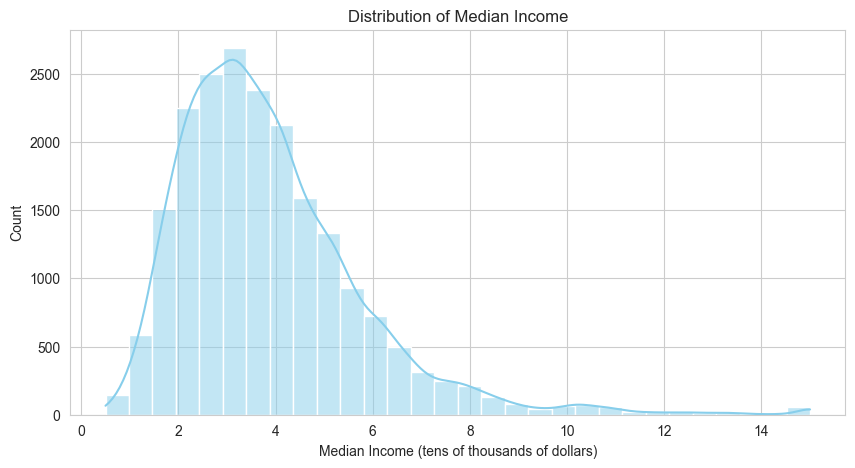

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MedInc'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Median Income')
plt.xlabel('Median Income (tens of thousands of dollars)')
plt.ylabel('Count')
plt.show()

### Insight from plot 1
- The majority of districts have median income values clustered around the lower and middle ranges.
- There are fewer very high-income districts, so the income distribution is right-skewed.

## 4. Plot 2: Geographical map of median house value

Use latitude and longitude to visualize how house values vary across California.

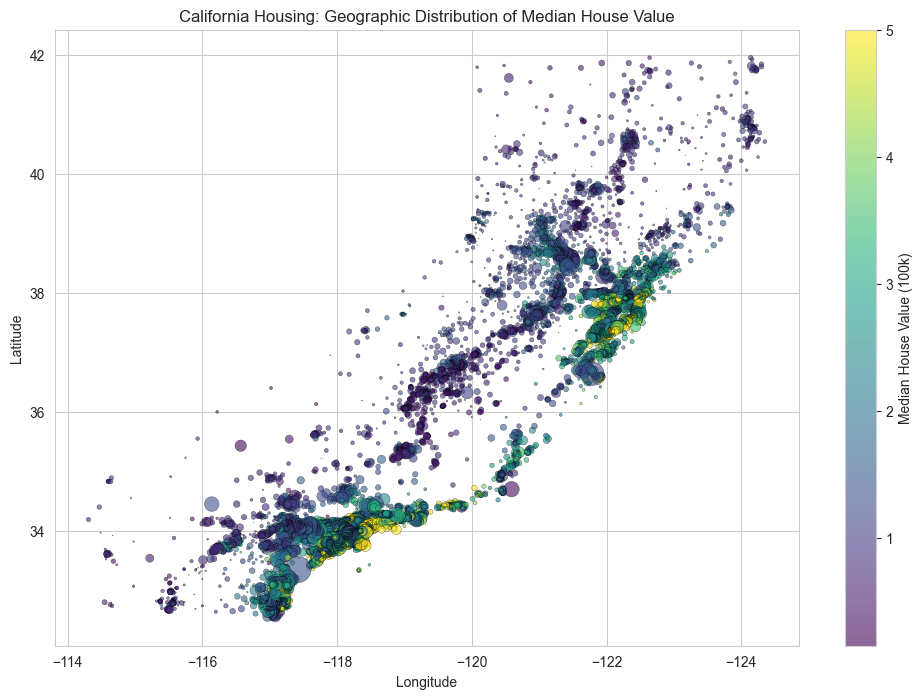

In [4]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    cmap='viridis',
    s=df['Population'] / 100,
    alpha=0.6,
    edgecolor='k',
    linewidth=0.3
)
plt.colorbar(scatter, label='Median House Value (100k)')
plt.title('California Housing: Geographic Distribution of Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().invert_xaxis()
plt.show()

### Insight from plot 2
- Higher house values are concentrated near the coast and in the northern part of the dataset.
- Lower values appear more inland, which suggests a geographic relationship between location and price.

## 5. Optional extra visualization

A quick scatter plot of rooms versus median house value can reveal another pattern.

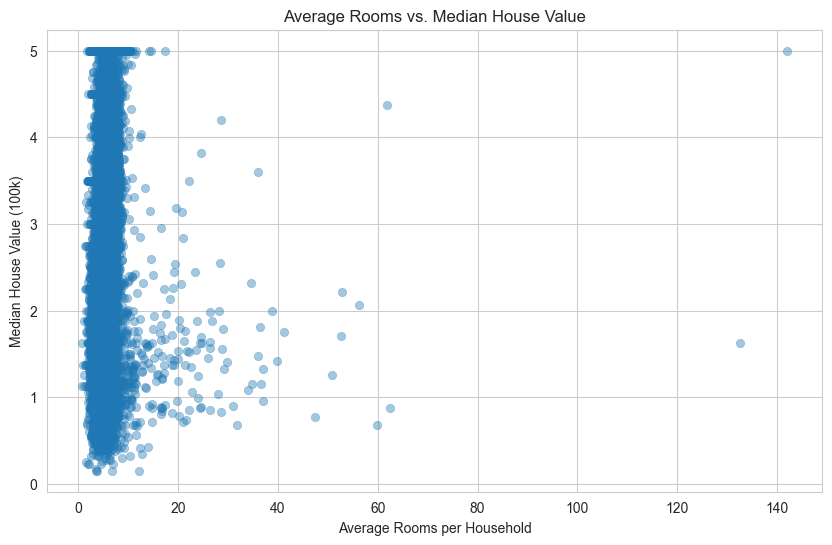

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['AveRooms'],
    y=df['MedHouseVal'],
    alpha=0.4,
    edgecolor=None
)
plt.title('Average Rooms vs. Median House Value')
plt.xlabel('Average Rooms per Household')
plt.ylabel('Median House Value (100k)')
plt.show()

### Insight from extra plot
- There is a weak positive relationship between average rooms and house value, but the data is noisy.
- Extreme room counts do not always correspond to higher prices, indicating other factors matter too.

## 6. Summary

- The dataset shows income is skewed toward lower and middle ranges.
- Geographic location strongly affects house value.
- Additional feature relationships can be explored further with more plots.